In [1]:
import torch
import numpy as np
import random
import os
import pandas as pd
import seaborn as sns
import torch.optim as optim
import matplotlib.pyplot as plt
from pyepo.func import SPOPlus
import math

# Set seed function generated by Google Gemini
def set_seeds(seed=42):
    """
    Sets random seeds for Python, NumPy, and PyTorch to ensure 
    reproducible results.
    """
    # 1. Set the Python built-in random module seed
    random.seed(seed)
    
    # 2. Set the NumPy seed
    np.random.seed(seed)
    
    # 3. Set the PyTorch seeds
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # If using multi-GPU
    
    # 4. Ensure deterministic behavior in CuDNN (if using GPU)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # 5. Set environment variable for hash seed
    os.environ['PYTHONHASHSEED'] = str(seed)

    print(f"Random seeds set to {seed}")

# Run
set_seeds(42)

plt.rcParams.update({
    "text.usetex": False,            # Turn off external LaTeX compiler
    "font.family": "serif",          # Use serif fonts
    "mathtext.fontset": "cm",        # Use Computer Modern for math/LaTeX text
    "font.serif": ["cmr10", "Computer Modern Roman"], # Try cmr10 first, fallback to CM Roman
    "axes.formatter.use_mathtext": True
})

Random seeds set to 42


In [2]:
dfV = pd.read_csv("HELMET_Triangular_Targets.csv")
dfV

,ptid_idx,hour,true_scans,interpolated_mls_class,last_known_mls_class,proba_0,proba_1,proba_2,proba_3,ipw,kld,proxy_reward
0,1,0,0,0,NaN,0.445908,0.318474,0.118668,0.116950,1.000000,0.000000,0.0
1,1,1,1,0,0.0,0.455688,0.282771,0.137140,0.124401,1.000000,0.003788,0.0
2,1,2,0,0,0.0,0.455688,0.282771,0.137140,0.124401,1.034962,0.000000,0.0
3,1,3,0,0,0.0,0.455688,0.282771,0.137140,0.124401,1.034365,0.000000,0.0
4,1,4,0,0,0.0,0.455688,0.282771,0.137140,0.124401,1.033779,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
138476,674,332,0,1,1.0,0.144472,0.489204,0.258802,0.107521,1.000063,0.000028,0.0
138477,674,333,0,1,1.0,0.144472,0.489204,0.258802,0.107521,1.000067,0.000000,0.0
138478,674,334,0,1,1.0,0.143071,0.479518,0.274290,0.103121,1.000045,0.000649,0.0
138479,674,335,0,1,1.0,0.143071,0.479518,0.274290,0.103121,1.000065,0.000000,0.0


In [3]:
max_val = dfV['proxy_reward'].max()
print(max_val)

22.416175927166623


In [4]:
# Generated by Google Gemini

# 1. Get the indices where true_scans is 1
scan_indices = dfV.index[dfV['true_scans'] == 1].tolist()

# 2. Calculate the differences between consecutive indices
if len(scan_indices) > 1:
    intervals = np.diff(scan_indices)
    
    # 3. Find the minimum interval
    min_interval = intervals.min()
    
    print(f"The smallest interval between true_scans is: {min_interval}")
    
    # Optional: See how many times this minimum interval occurs
    count_min = np.sum(intervals == min_interval)
    print(f"This minimum interval occurs {count_min} time(s).")
else:
    print("Not enough true_scans found to calculate an interval.")

The smallest interval between true_scans is: 1
This minimum interval occurs 140 time(s).


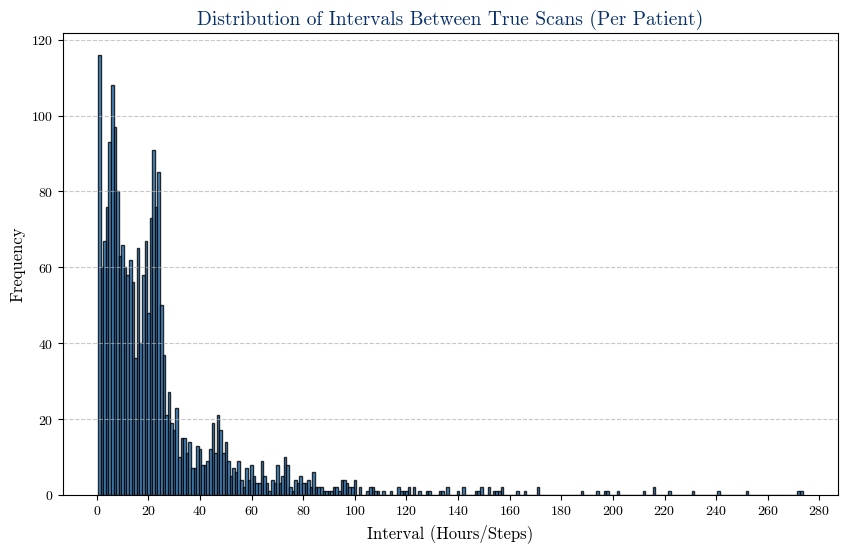

In [21]:
# Generated by Google Gemini and modified by me

# 1. Calculate intervals within each patient group
all_intervals = []
for ptid, group in dfV.groupby('ptid_idx'):
    scan_indices = group.index[group['true_scans'] == 1].tolist()
    if len(scan_indices) > 1:
        intervals = np.diff(scan_indices)
        all_intervals.extend(intervals)

# 2. Plot the distribution
if all_intervals:
    plt.figure(figsize=(10, 6))
    bins = np.arange(min(all_intervals), max(all_intervals) + 2) - 0.5
    
    # Updated color and alpha to match total_scans_distribution.png
    plt.hist(all_intervals, bins=bins, edgecolor='black', color='#2171b5', alpha=0.8)
    
    plt.title('Distribution of Intervals Between True Scans (Per Patient)', fontsize=14, color='#08306b')
    plt.xlabel('Interval (Hours/Steps)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    
    tick_step = 20
    plt.xticks(np.arange(0, max(all_intervals) + tick_step, tick_step))
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Save plot BEFORE plt.show()
    plt.savefig('interval_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

--- Scan Volume Metrics ---
Maximum scans received: 19 (Patient ID: [75])
Minimum scans received: 1
Mean scans per patient: 4.54
Median scans per patient: 4.0


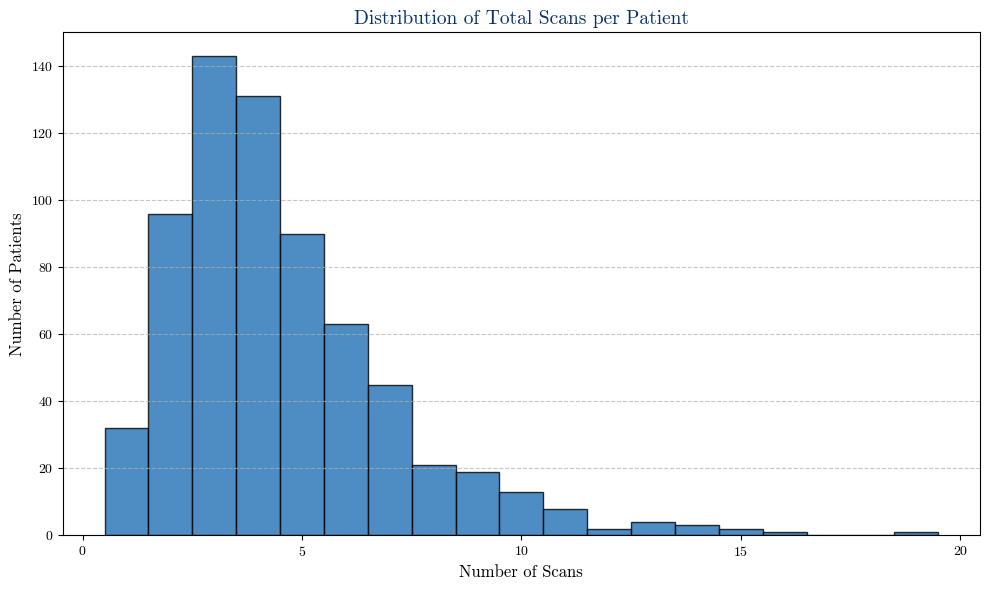

In [7]:
# Generated by Google Gemini and modified by me

# 1. Calculate the number of scans per patient
scans_per_patient = dfV.groupby('ptid_idx')['true_scans'].sum()

# 2. Extract metrics
max_scans = scans_per_patient.max()
min_scans = scans_per_patient.min()
mean_scans = scans_per_patient.mean()
median_scans = scans_per_patient.median()

# Identify the patient(s) with the maximum number of scans
top_patients = scans_per_patient[scans_per_patient == max_scans].index.tolist()

print(f"--- Scan Volume Metrics ---")
print(f"Maximum scans received: {max_scans} (Patient ID: {top_patients})")
print(f"Minimum scans received: {min_scans}")
print(f"Mean scans per patient: {mean_scans:.2f}")
print(f"Median scans per patient: {median_scans}")

# 3. Plot the distribution
plt.figure(figsize=(10, 6))
bins = np.arange(min_scans, max_scans + 2) - 0.5

# Changed color to darkblue
plt.hist(scans_per_patient, bins=bins, edgecolor='black', color='#2171b5', alpha=0.8)

plt.title('Distribution of Total Scans per Patient', fontsize=14, color='#08306b')
plt.xlabel('Number of Scans', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

tick_step = 5 if max_scans < 50 else 10
plt.xticks(np.arange(0, max_scans + tick_step, tick_step))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save plot BEFORE plt.show()
plt.savefig('total_scans_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

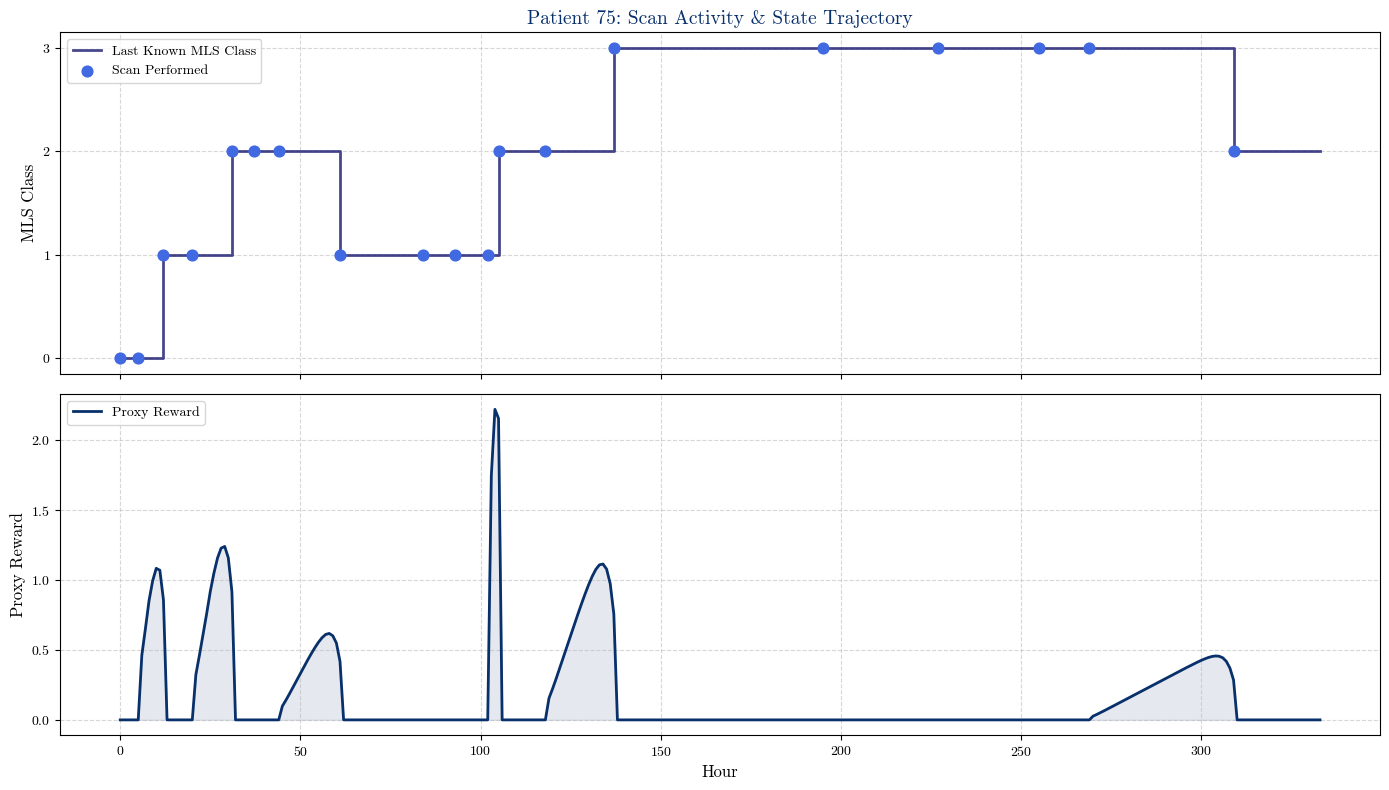

In [10]:
# Generated by Google Gemini

# 1. Filter for Patient 75
df_75 = dfV[dfV['ptid_idx'] == 75].copy()

# 2. Set up the figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- Top Plot: State Trajectory and Scans ---
# Changed color to midnightblue
ax1.step(df_75['hour'], df_75['last_known_mls_class'], where='post', color='midnightblue', label='Last Known MLS Class', alpha=0.8, linewidth=2)

# Overlay markers - Changed color to royalblue for contrast against the dark line
scans = df_75[df_75['true_scans'] == 1]
ax1.scatter(scans['hour'], scans['last_known_mls_class'], color='royalblue', marker='o', s=60, label='Scan Performed', zorder=5)

ax1.set_ylabel('MLS Class', fontsize=12)
ax1.set_title('Patient 75: Scan Activity & State Trajectory', fontsize=14, color='#08306b')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')
ax1.set_yticks([0, 1, 2, 3])

# --- Bottom Plot: Proxy Reward Curve ---
ax2.plot(df_75['hour'], df_75['proxy_reward'], linewidth=2, label='Proxy Reward', color='#08306b')
ax2.fill_between(df_75['hour'], df_75['proxy_reward'], alpha=0.1, color='#08306b')

ax2.set_ylabel('Proxy Reward', fontsize=12)
ax2.set_xlabel('Hour', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper left')

plt.tight_layout()

# Save plot BEFORE plt.show()
plt.savefig('patient_75_trajectory.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
# Generated by Google Gemini

from scipy.signal import find_peaks
def get_peak_indices_tuned(rewards, threshold=0.028):
    """
    Robust Peak Detection.
    - Captures all local maxima above the threshold.
    - Handles "flat" peaks (plateaus).
    - Robustly includes start/end points.
    """
    T = len(rewards)
    if T == 0:
        return []
        
    # 1. Find standard peaks (using distance to suppress noise neighbors)
    # distance=4 prevents selecting two points within 4 hours of each other
    peaks, _ = find_peaks(rewards, height=threshold, prominence=1e-5)
    candidates = set(peaks)

    # 2. Handle Global Max (in case find_peaks missed a weird edge case)
    glob_max_idx = np.argmax(rewards)
    if rewards[glob_max_idx] >= threshold:
        candidates.add(glob_max_idx)

    # 3. Handle Endpoints with "Greater Than or Equal" logic
    # Start: Peak if higher/equal to neighbor
    if T > 0 and rewards[0] >= threshold:
        if T == 1 or rewards[0] >= rewards[1]: 
             candidates.add(0)

    # End: Peak if higher/equal to neighbor
    if T > 1 and rewards[-1] >= threshold:
        if rewards[-1] >= rewards[-2]: 
             candidates.add(T-1)
             
    # Return sorted unique list
    return sorted(list(candidates))

Maximum number of peaks found: 9
Patient(s) with the most peaks: [529]


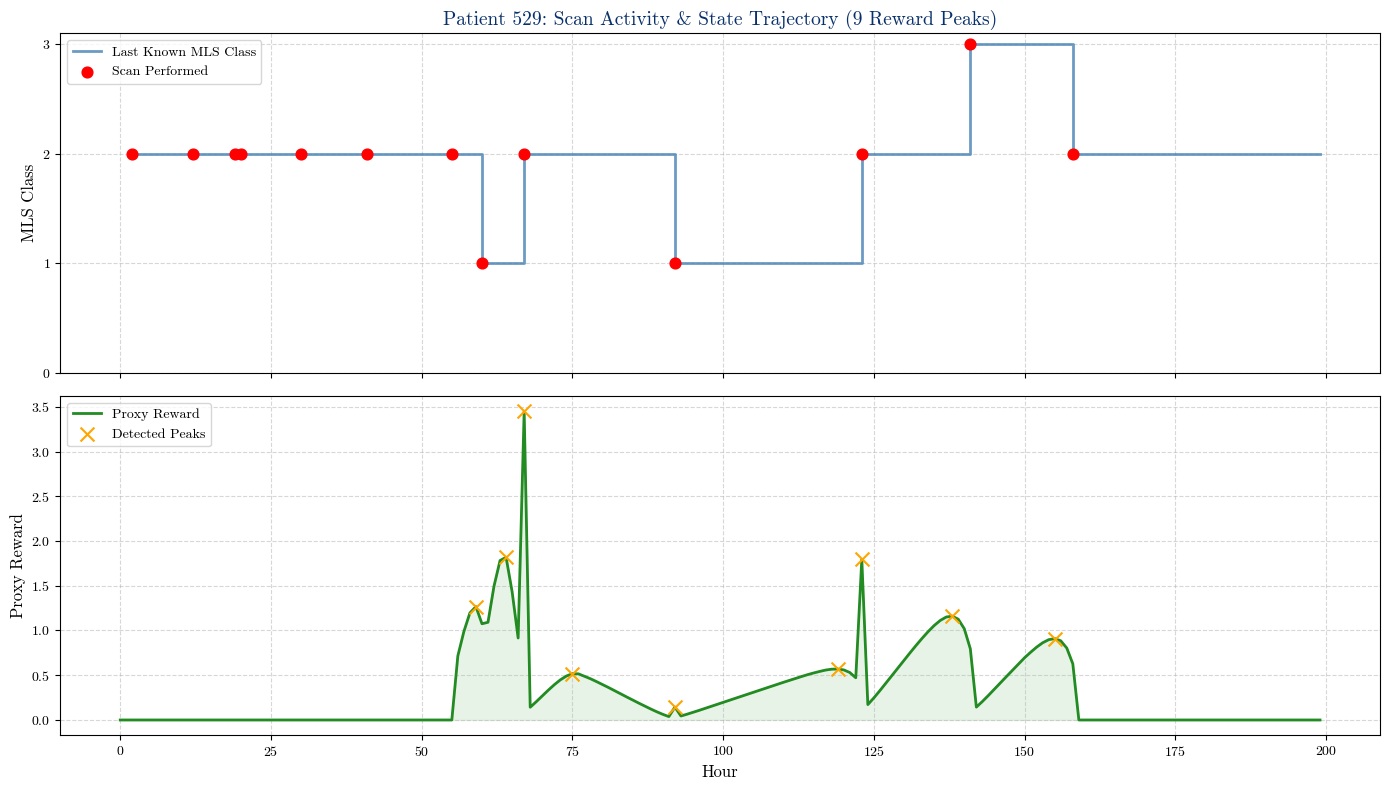

In [12]:
# Generated by Google Gemini

import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate peaks for every patient
peak_counts = {}

for ptid, group in dfV.groupby('ptid_idx'):
    rewards = group['proxy_reward'].values
    peaks = get_peak_indices_tuned(rewards)
    peak_counts[ptid] = len(peaks)

# 2. Find the patient(s) with the maximum number of peaks
max_peaks = max(peak_counts.values())
top_peak_patients = [ptid for ptid, count in peak_counts.items() if count == max_peaks]

print(f"Maximum number of peaks found: {max_peaks}")
print(f"Patient(s) with the most peaks: {top_peak_patients}")

# 3. Visualize the first patient in the top list (usually one, but handles multiples)
target_ptid = top_peak_patients[0]
df_target = dfV[dfV['ptid_idx'] == target_ptid].copy()
target_peaks = get_peak_indices_tuned(df_target['proxy_reward'].values)

# Create the plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- Top Plot: State Trajectory and Scans ---
ax1.step(df_target['hour'], df_target['last_known_mls_class'], where='post', 
         color='steelblue', label='Last Known MLS Class', alpha=0.8, linewidth=2)

# Scans
scans = df_target[df_target['true_scans'] == 1]
ax1.scatter(scans['hour'], scans['last_known_mls_class'], 
            color='red', marker='o', s=60, label='Scan Performed', zorder=5)

ax1.set_ylabel('MLS Class', fontsize=12)
ax1.set_title(f'Patient {target_ptid}: Scan Activity & State Trajectory ({max_peaks} Reward Peaks)', fontsize=14, color='#08306b')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')
ax1.set_yticks([0, 1, 2, 3])

# --- Bottom Plot: Proxy Reward Curve & Peak Markers ---
ax2.plot(df_target['hour'], df_target['proxy_reward'], color='forestgreen', linewidth=2, label='Proxy Reward')
ax2.fill_between(df_target['hour'], df_target['proxy_reward'], color='forestgreen', alpha=0.1)

# Mark the peaks found by your function
peak_hours = df_target['hour'].iloc[target_peaks]
peak_values = df_target['proxy_reward'].iloc[target_peaks]
ax2.scatter(peak_hours, peak_values, color='orange', marker='x', s=100, label='Detected Peaks', zorder=5)

ax2.set_ylabel('Proxy Reward', fontsize=12)
ax2.set_xlabel('Hour', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [13]:
# Generated by Google Gemini

# 1. Initialize global delay tracker
global_delays = []
patients_with_matches = 0

# 2. Iterate through every patient in the dataset
for ptid, group in dfV.groupby('ptid_idx'):
    rewards = group['proxy_reward'].values
    
    # Get peak indices for this patient
    peaks = get_peak_indices_tuned(rewards)
    
    if not peaks:
        continue
        
    # Get actual scan hours
    scan_hours = group[group['true_scans'] == 1]['hour'].values
    peak_hours = group['hour'].iloc[peaks].values
    
    patient_has_match = False
    for ph in peak_hours:
        # Find the first scan that happened at or after this peak
        future_scans = scan_hours[scan_hours >= ph]
        if len(future_scans) > 0:
            delay = future_scans[0] - ph
            global_delays.append(delay)
            patient_has_match = True
            
    if patient_has_match:
        patients_with_matches += 1

# 3. Aggregate Statistics for the whole dataset
if global_delays:
    print(f"--- Global Delay Analysis (All Patients) ---")
    print(f"Total Patients Analyzed:     {dfV['ptid_idx'].nunique()}")
    print(f"Patients with Peak-Scan Matches: {patients_with_matches}")
    print(f"Total Peak-Scan Pairs Found:     {len(global_delays)}")
    print("-" * 40)
    print(f"Mean Delay (Reaction Time):  {np.mean(global_delays):.2f} hours")
    print(f"Median Delay:                {np.median(global_delays):.2f} hours")
    print(f"Standard Deviation:          {np.std(global_delays):.2f} hours")
    print(f"Max Delay Observed:          {np.max(global_delays):.2f} hours")
else:
    print("No peak-scan pairs were found across the dataset.")

--- Global Delay Analysis (All Patients) ---
Total Patients Analyzed:     674
Patients with Peak-Scan Matches: 448
Total Peak-Scan Pairs Found:     1053
----------------------------------------
Mean Delay (Reaction Time):  6.08 hours
Median Delay:                3.00 hours
Standard Deviation:          12.24 hours
Max Delay Observed:          244.00 hours


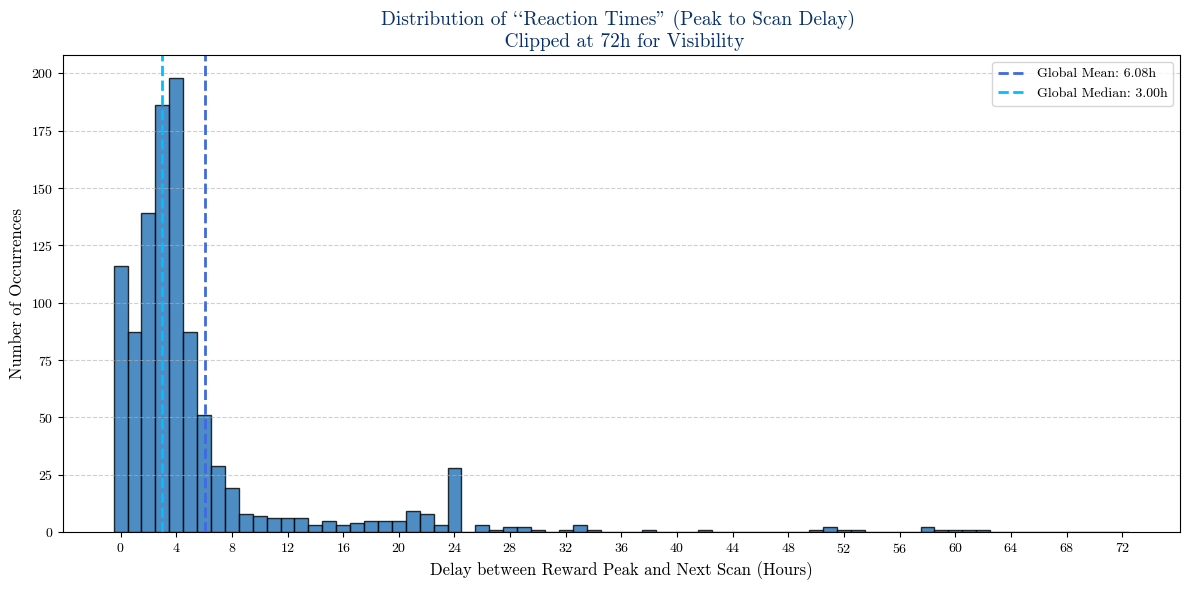

In [20]:
# Generated by Google Gemini and modified by me

# 1. Define the plot range
max_plot_range = 72
plt.figure(figsize=(12, 6))

# 2. Create the histogram
bins = np.arange(0, max_plot_range + 2) - 0.5
# Changed color to darkblue
plt.hist(global_delays, bins=bins, edgecolor='black', color='#2171b5', alpha=0.8)

# 3. Add statistical reference lines - Changed to contrasting blue shades
mean_val = np.mean(global_delays)
median_val = np.median(global_delays)
plt.axvline(mean_val, color='royalblue', linestyle='dashed', linewidth=2, label=f'Global Mean: {mean_val:.2f}h')
plt.axvline(median_val, color='deepskyblue', linestyle='dashed', linewidth=2, label=f'Global Median: {median_val:.2f}h')

# 4. Formatting
plt.title(f'Distribution of ``Reaction Times" (Peak to Scan Delay) \n Clipped at {max_plot_range}h for Visibility', fontsize=14, color='#08306b')
plt.xlabel('Delay between Reward Peak and Next Scan (Hours)', fontsize=12)
plt.ylabel('Number of Occurrences', fontsize=12)
plt.xticks(np.arange(0, max_plot_range + 4, 4))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Save plot BEFORE plt.show()
plt.savefig('reaction_times_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Mean: 29.13
Median: 16.00
Min: 2
Max: 304
Std Dev: 41.46
Total Count: 605


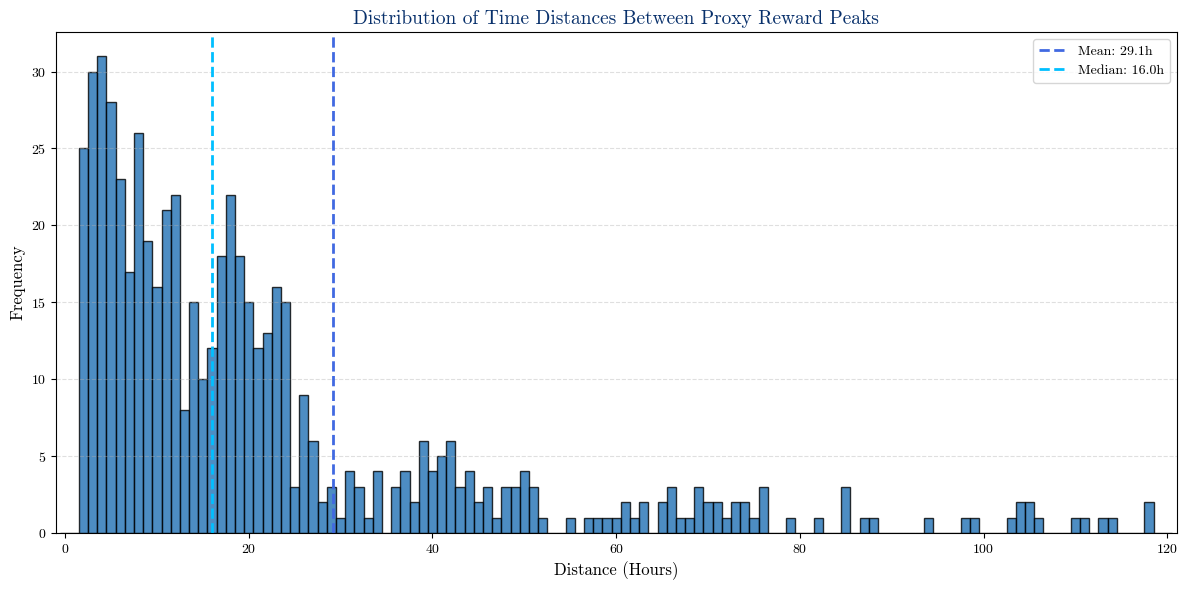

In [15]:
# Generated by Google Gemini and modified by me

import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate distances between consecutive peaks within each patient
all_peak_distances = []

for ptid, group in dfV.groupby('ptid_idx'):
    rewards = group['proxy_reward'].values
    peaks = get_peak_indices_tuned(rewards) # Uses the function defined earlier

    if len(peaks) > 1:
        # Calculate time (hour) difference between consecutive peaks
        peak_hours = group['hour'].iloc[peaks].values
        distances = np.diff(peak_hours)
        all_peak_distances.extend(distances)

# 2. Extract Metrics
if all_peak_distances:
    metrics = {
        "Mean": np.mean(all_peak_distances),
        "Median": np.median(all_peak_distances),
        "Min": np.min(all_peak_distances),
        "Max": np.max(all_peak_distances),
        "Std Dev": np.std(all_peak_distances),
        "Total Count": len(all_peak_distances)
    }

    for key, val in metrics.items():
        print(f"{key}: {val:.2f}" if isinstance(val, float) else f"{key}: {val}")

# 3. Plot the Histogram
    plt.figure(figsize=(12, 6))

    # Use a reasonable range for visibility (e.g., up to 120 hours)
    plot_limit = 120
    bins = np.arange(0, min(max(all_peak_distances), plot_limit) + 2) - 0.5
    
    # Changed color to darkblue
    plt.hist(all_peak_distances, bins=bins, color='#2171b5', edgecolor='black', alpha=0.8)

    # Formatting
    plt.title('Distribution of Time Distances Between Proxy Reward Peaks', fontsize=14, color='#08306b')
    plt.xlabel('Distance (Hours)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.xlim(-1, plot_limit + 1)

    # Add vertical lines for mean and median - Changed to contrasting blue shades
    plt.axvline(metrics["Mean"], color='royalblue', linestyle='dashed', linewidth=2, label=f'Mean: {metrics["Mean"]:.1f}h')
    plt.axvline(metrics["Median"], color='deepskyblue', linestyle='dashed', linewidth=2, label=f'Median: {metrics["Median"]:.1f}h')

    plt.legend()
    plt.tight_layout()
    
    # Save plot BEFORE plt.show()
    plt.savefig('peak_distances_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

else:
    print("No peak intervals found to analyze.")

Patients with a minimum scan interval of 1: [21, 38, 49, 53, 62, 82, 116, 125, 146, 187]...


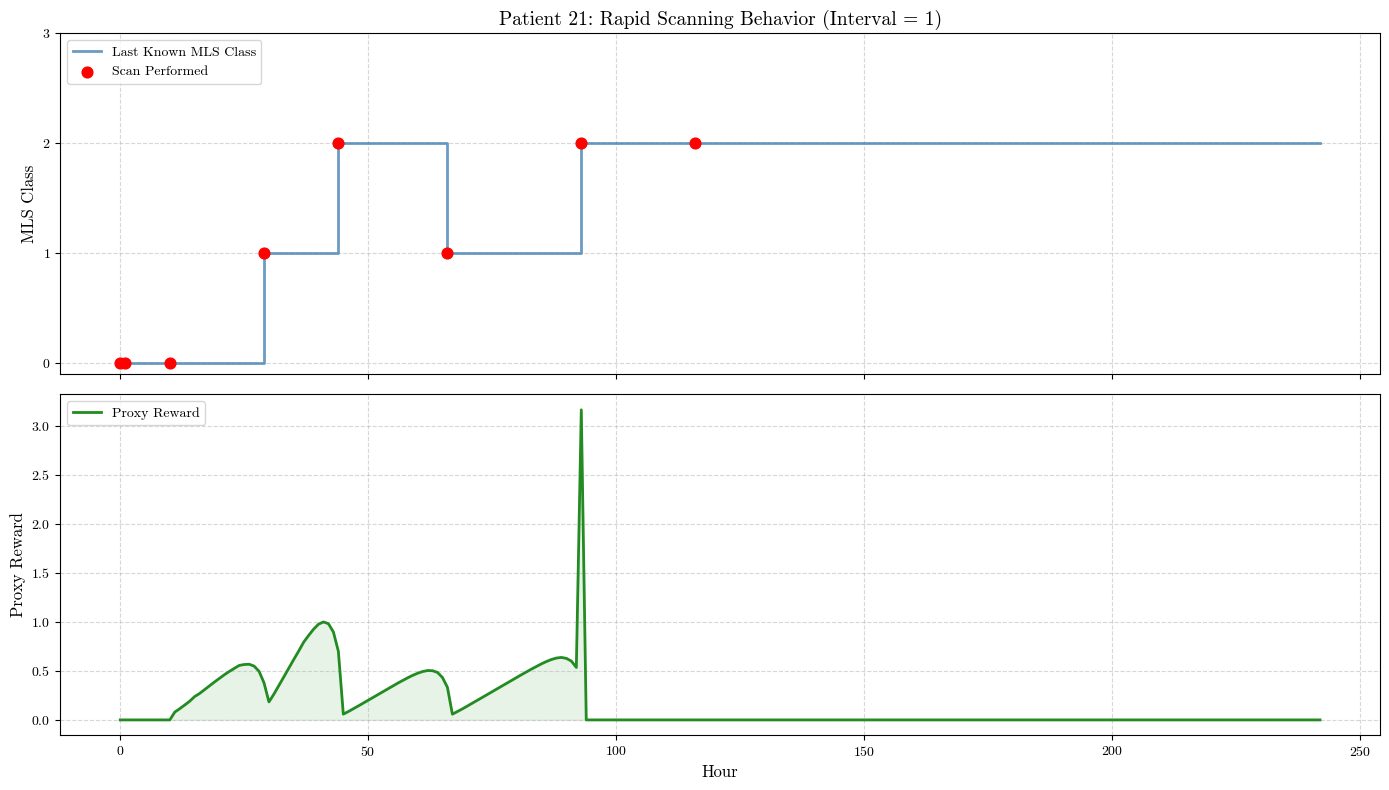

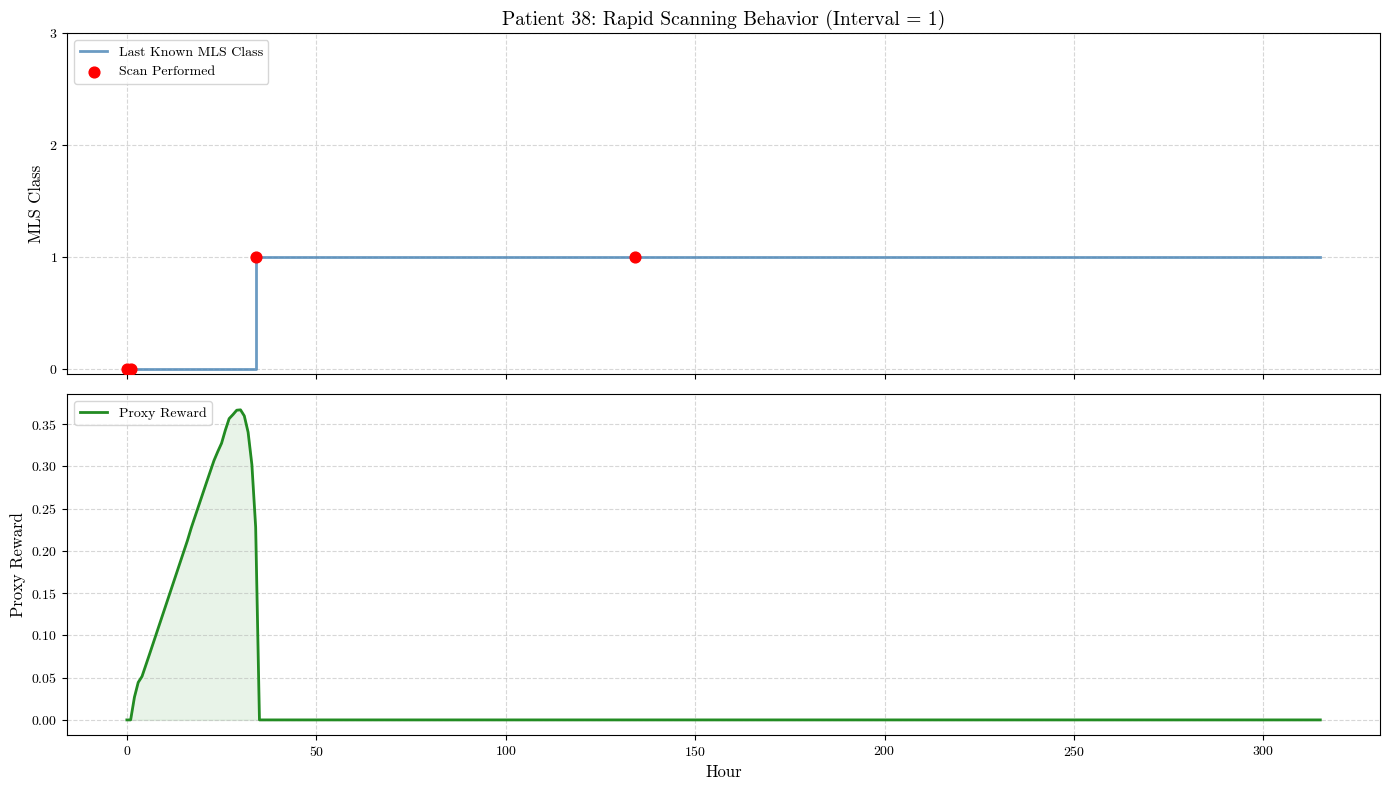

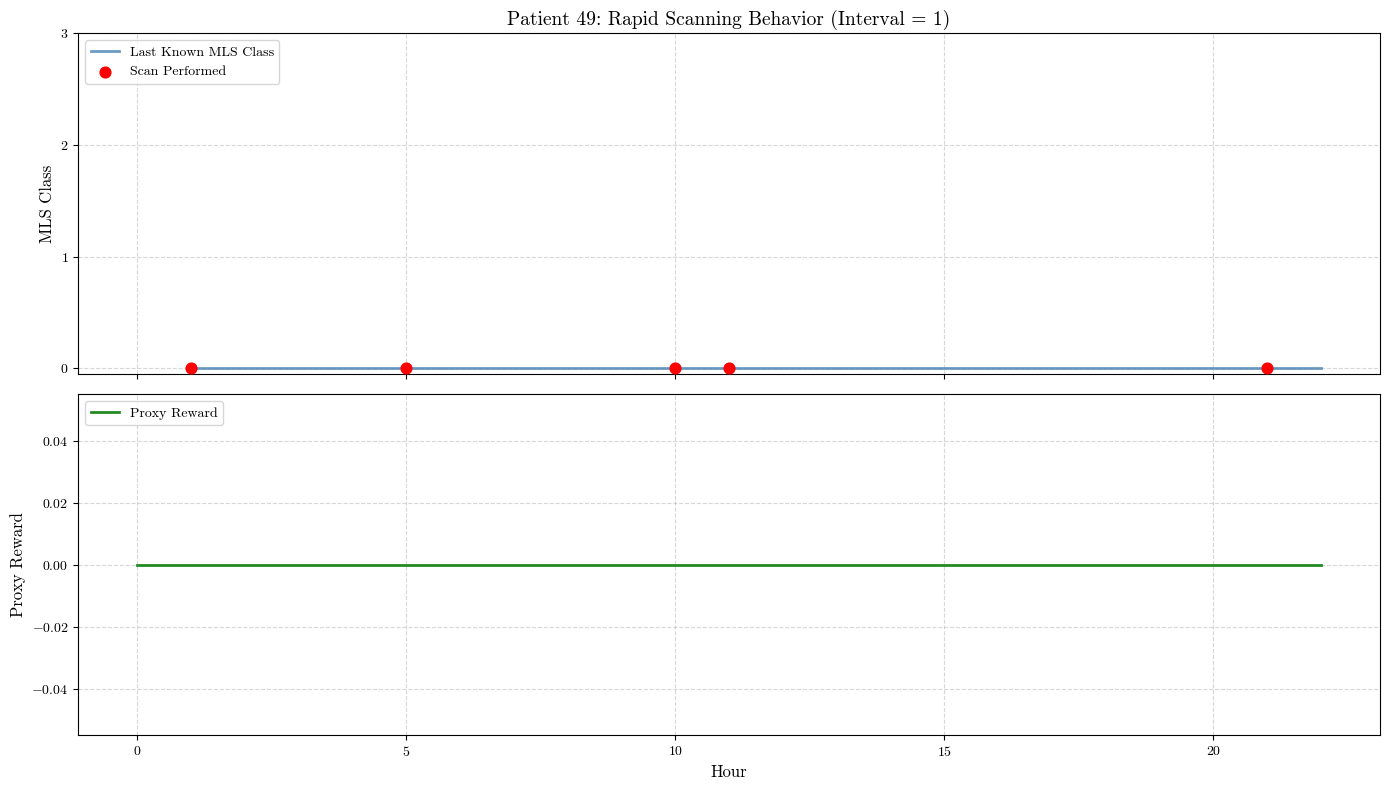

In [16]:
# Generated by Google Gemini

# 1. Identify patients with at least one interval of 1
patients_with_unit_interval = []

for ptid, group in dfV.groupby('ptid_idx'):
    scan_indices = group.index[group['true_scans'] == 1].tolist()
    if len(scan_indices) > 1:
        intervals = np.diff(scan_indices)
        if 1 in intervals:
            patients_with_unit_interval.append(ptid)

print(f"Patients with a minimum scan interval of 1: {patients_with_unit_interval[:10]}...")

# 2. Select a few patients to visualize (e.g., the first 3)
selected_patients = patients_with_unit_interval[:3]

for target_ptid in selected_patients:
    df_target = dfV[dfV['ptid_idx'] == target_ptid].copy()
    
    # Set up the figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # --- Top Plot: State Trajectory and Scans ---
    ax1.step(df_target['hour'], df_target['last_known_mls_class'], where='post', 
             color='steelblue', label='Last Known MLS Class', alpha=0.8, linewidth=2)

    # Overlay scans
    scans = df_target[df_target['true_scans'] == 1]
    ax1.scatter(scans['hour'], scans['last_known_mls_class'], 
                color='red', marker='o', s=60, label='Scan Performed', zorder=5)

    ax1.set_ylabel('MLS Class', fontsize=12)
    ax1.set_title(f'Patient {target_ptid}: Rapid Scanning Behavior (Interval = 1)', fontsize=14)
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='upper left')
    ax1.set_yticks([0, 1, 2, 3])

    # --- Bottom Plot: Proxy Reward Curve ---
    ax2.plot(df_target['hour'], df_target['proxy_reward'], color='forestgreen', linewidth=2, label='Proxy Reward')
    ax2.fill_between(df_target['hour'], df_target['proxy_reward'], color='forestgreen', alpha=0.1)

    ax2.set_ylabel('Proxy Reward', fontsize=12)
    ax2.set_xlabel('Hour', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

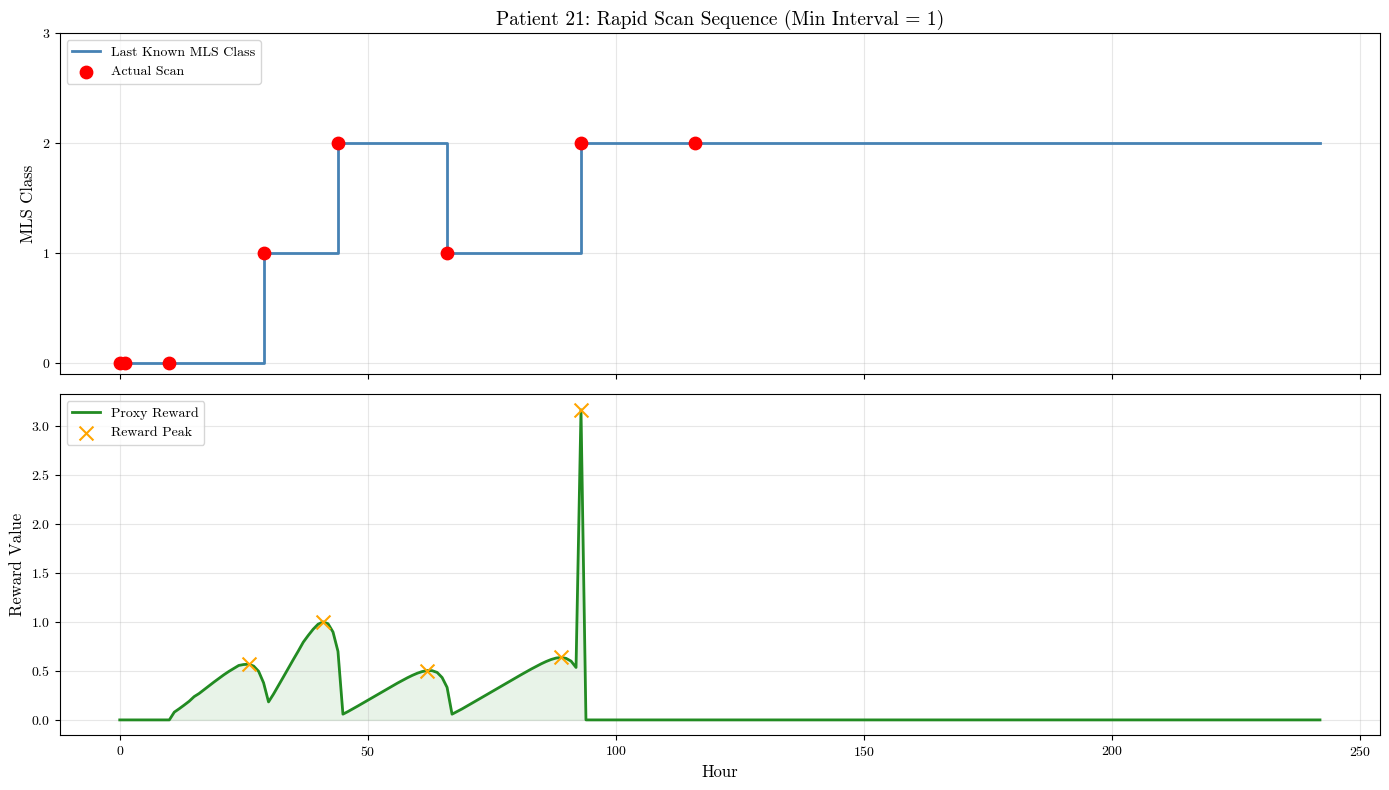

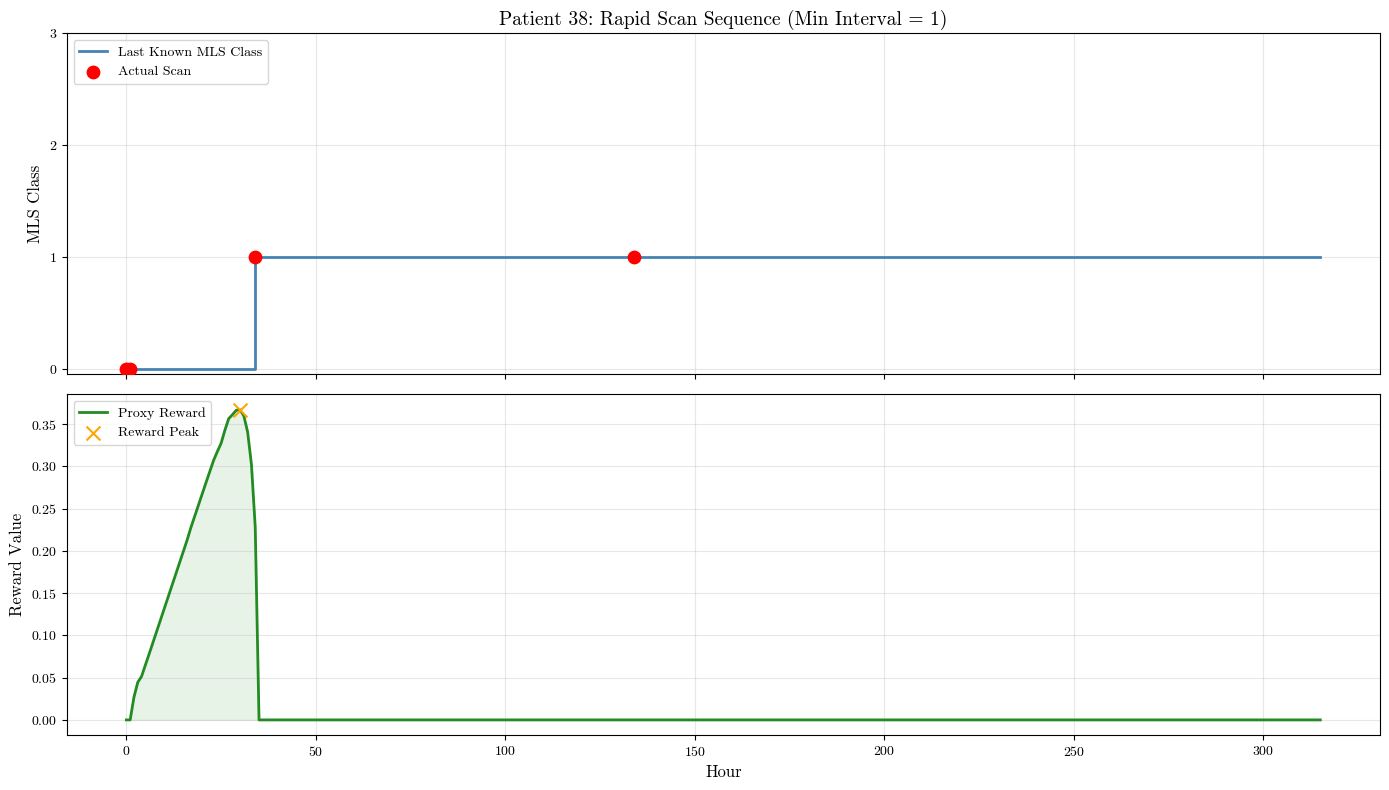

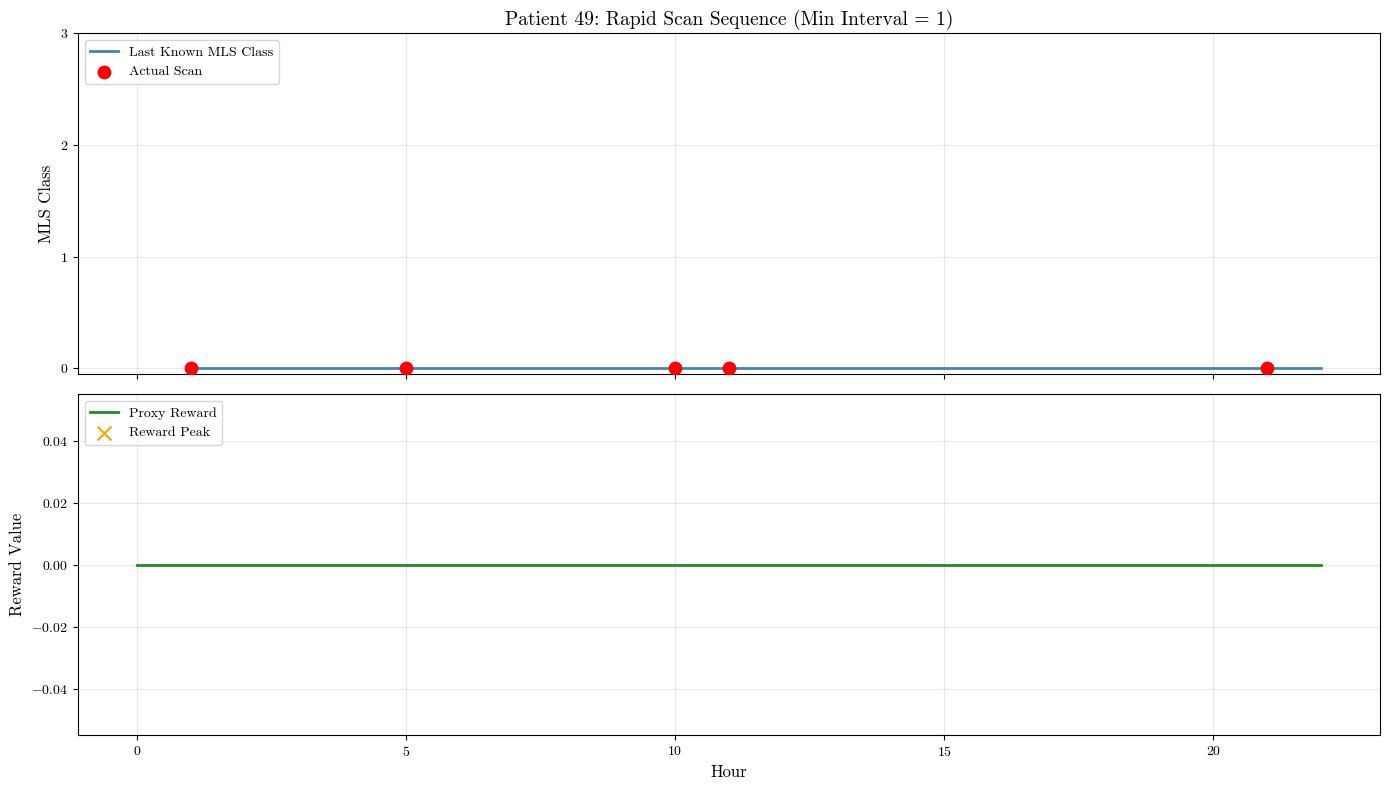

In [17]:
# Generated by Google Gemini

# Select the first 3 patients with unit intervals
selected_ptids = [21, 38, 49]

for ptid in selected_ptids:
    df_p = dfV[dfV['ptid_idx'] == ptid].copy()
    
    # Calculate peaks for this specific patient
    rewards = df_p['proxy_reward'].values
    peaks = get_peak_indices_tuned(rewards)
    peak_hours = df_p['hour'].iloc[peaks].values
    peak_values = df_p['proxy_reward'].iloc[peaks].values

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # --- Top Plot: State Trajectory and Scans ---
    ax1.step(df_p['hour'], df_p['last_known_mls_class'], where='post', 
             color='steelblue', label='Last Known MLS Class', linewidth=2)
    
    # Actual Scans
    scans = df_p[df_p['true_scans'] == 1]
    ax1.scatter(scans['hour'], scans['last_known_mls_class'], 
                color='red', marker='o', s=80, label='Actual Scan', zorder=5)

    ax1.set_title(f'Patient {ptid}: Rapid Scan Sequence (Min Interval = 1)', fontsize=14)
    ax1.set_ylabel('MLS Class', fontsize=12)
    ax1.set_yticks([0, 1, 2, 3])
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper left')

    # --- Bottom Plot: Proxy Reward & Peaks ---
    ax2.plot(df_p['hour'], df_p['proxy_reward'], color='forestgreen', label='Proxy Reward', linewidth=2)
    ax2.fill_between(df_p['hour'], df_p['proxy_reward'], color='forestgreen', alpha=0.1)
    
    # Detected Peaks
    ax2.scatter(peak_hours, peak_values, color='orange', marker='x', s=100, label='Reward Peak', zorder=5)

    ax2.set_ylabel('Reward Value', fontsize=12)
    ax2.set_xlabel('Hour', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

In [18]:
# Generated by Google Gemini

# 1. Initialize counters for transitions
transitions = []

# 2. Iterate through each patient to find Interval = 1 events
for ptid, group in dfV.groupby('ptid_idx'):
    # Get indices where scans occurred
    scan_indices = group.index[group['true_scans'] == 1].tolist()
    
    if len(scan_indices) > 1:
        for i in range(len(scan_indices) - 1):
            idx1 = scan_indices[i]
            idx2 = scan_indices[i+1]
            
            # Check if the scans are exactly 1 hour apart
            if idx2 - idx1 == 1:
                # State at first scan
                state_start = group.loc[idx1, 'last_known_mls_class']
                # State discovered at second scan
                state_end = group.loc[idx2, 'last_known_mls_class']
                
                transitions.append((state_start, state_end))

# 3. Create a DataFrame to count frequencies
df_trans = pd.DataFrame(transitions, columns=['From', 'To'])
transition_counts = df_trans.groupby(['From', 'To']).size().reset_index(name='Frequency')

# 4. Map to LaTeX table categories
def categorize(row):
    if row['From'] == 0 and row['To'] == 1: return "Initial Progression"
    if row['From'] == 1 and row['To'] == 2: return "Moderate Progression"
    if row['From'] == 2 and row['To'] == 3: return "Critical Progression"
    if row['From'] == row['To']: return "Stable / Monitoring"
    return "Other"

transition_counts['Category'] = transition_counts.apply(categorize, axis=1)
final_table = transition_counts.groupby('Category')['Frequency'].sum().reset_index()

print(final_table)

               Category  Frequency
0   Initial Progression          4
1  Moderate Progression          1
2                 Other          4
3   Stable / Monitoring        107


               Category  Frequency
0  Critical Progression          4
1   Initial Progression          4
2  Moderate Progression          1
3   Stable / Monitoring        107


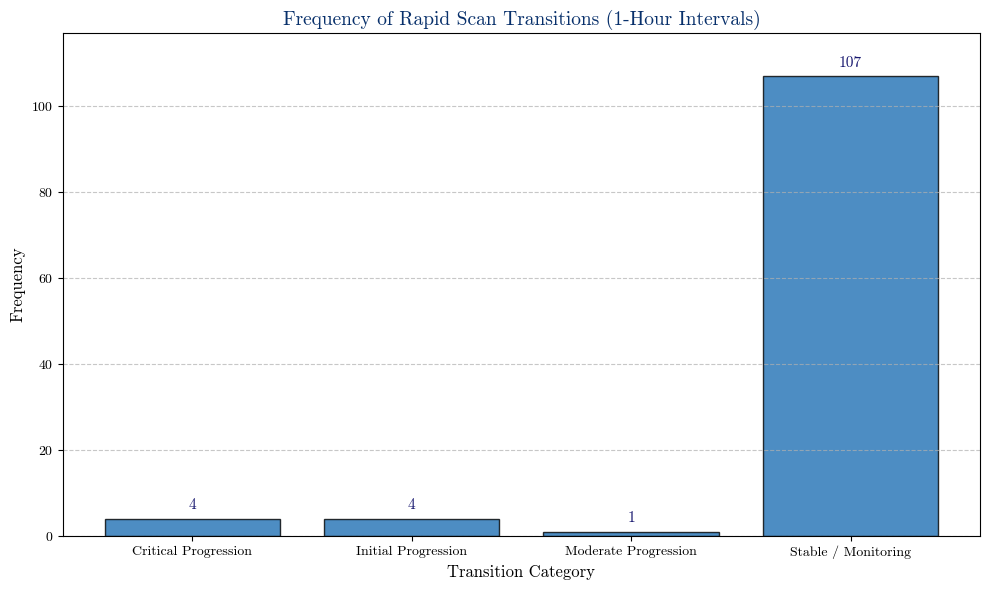

In [19]:
# Generated by Google Gemini and modified by me

import pandas as pd
import matplotlib.pyplot as plt

# 1. Initialize counters for transitions
transitions = []

# 2. Iterate through each patient to find Interval = 1 events
for ptid, group in dfV.groupby('ptid_idx'):
    # Get indices where scans occurred
    scan_indices = group.index[group['true_scans'] == 1].tolist()
    
    if len(scan_indices) > 1:
        for i in range(len(scan_indices) - 1):
            idx1 = scan_indices[i]
            idx2 = scan_indices[i+1]
            
            # Check if the scans are exactly 1 hour apart
            if idx2 - idx1 == 1:
                # State at first scan
                state_start = group.loc[idx1, 'last_known_mls_class']
                # State discovered at second scan
                state_end = group.loc[idx2, 'last_known_mls_class']
                transitions.append((state_start, state_end))

# 3. Create a DataFrame to count frequencies
df_trans = pd.DataFrame(transitions, columns=['From', 'To'])
transition_counts = df_trans.groupby(['From', 'To']).size().reset_index(name='Frequency')

# 4. Map to LaTeX table categories
def categorize(row):
    if row['From'] == 0 and row['To'] == 1:
        return "Initial Progression"
    if row['From'] == 1 and row['To'] == 2:
        return "Moderate Progression"
    if row['From'] == 2 and row['To'] == 3:
        return "Critical Progression"
    if row['From'] == row['To']:
        return "Stable / Monitoring"
    return "Critical Progression"

transition_counts['Category'] = transition_counts.apply(categorize, axis=1)
final_table = transition_counts.groupby('Category')['Frequency'].sum().reset_index()

print(final_table)

# 5. Plot the Bar Chart
plt.figure(figsize=(10, 6))

# Plotting the categorical bars using our consistent dark blue palette
bars = plt.bar(final_table['Category'], final_table['Frequency'], 
               color='#2171b5', edgecolor='black', alpha=0.8)

# Formatting
plt.title('Frequency of Rapid Scan Transitions (1-Hour Intervals)', fontsize=14, color='#08306b')
plt.xlabel('Transition Category', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of each bar (helpful since "Stable" is so much larger than the rest)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1.5, int(yval), 
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='midnightblue')

# Stretch the y-axis slightly to make room for the highest text label
plt.ylim(0, final_table['Frequency'].max() + 10)
plt.tight_layout()

# Save plot BEFORE plt.show()
plt.savefig('rapid_scan_transitions_bar.png', dpi=300, bbox_inches='tight')
plt.show()